# Notebook 12 — Heterogeneous Heads Architecture
## The fix for the DeltaNet BPC gap

### Why VLA loses BPC to DeltaNet (the real diagnosis)
DeltaNet uses a **scalar forget gate** — it decays the full state and reuses
capacity at each step. This is lossy but it keeps the effective memory fresh.

VLA uses **A_t accumulation** — penalty mass builds up and eventually
all directions are penalised. At d_h=64, the state saturates after ~200 tokens
of real text. Language modeling needs to track patterns across 256+ tokens.

### The fix: Heterogeneous Heads
- **Fast heads** (d_h=64, H=4): short-range, recent context — same as before
- **Slow heads** (d_h=256, H=2): long-range, large capacity — new

Total capacity: 4×64 + 2×256 = 768 associations vs 8×64 = 512 for uniform.
Each head still satisfies Proposition 2 (sv=1) independently.
The Corollary: "Hetero-VLA capacity = sum of per-head capacities."

### Expected result
- Hetero-VLA BPC closer to DeltaNet (target: gap < 5%)
- State norm still bounded (Prop 1 holds per head)
- New architecture contribution for v2 paper

## 0 · Setup

In [1]:
import math, time, gc, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT    = Path('/kaggle/working/nb12_hetero')
for sub in ['plots','logs','ckpt']:
    (OUT/sub).mkdir(parents=True, exist_ok=True)

matplotlib.rcParams.update({
    'font.family':'DejaVu Serif','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.25,'figure.dpi':150,
})
C = {'vla':'#00B894','hetero':'#0984E3','linear':'#E17055',
     'deltanet':'#FDCB6E','vla_uniform':'#55EFC4'}
M = {'vla':'D','hetero':'*','linear':'s','deltanet':'^'}

print(f'Device: {DEVICE}  |  Torch: {torch.__version__}')

Device: cuda  |  Torch: 2.11.0+cu128


## 1 · Config

In [2]:
# Shared model config
D_MODEL   = 256
N_LAYERS  = 3
D_FF      = 512
MAX_LEN   = 4096

# Training
STEPS     = 3_000
BATCH     = 4
SEQ_LEN   = 128
LR        = 3e-4
WARMUP    = 500
GRAD_CLIP = 1.0
EVAL_INT  = 500
SEED      = 42

# Hetero head configs to compare
CONFIGS = {

    'Uniform-VLA': {
        'fast_dh': 32,
        'fast_H': 4,
        'slow_dh': 32,
        'slow_H': 4,
    },

    'Hetero-VLA-2x': {
        'fast_dh': 16,
        'fast_H': 4,
        'slow_dh': 48,
        'slow_H': 4,
    },

    'Hetero-VLA-4x': {
        'fast_dh': 8,
        'fast_H': 4,
        'slow_dh': 56,
        'slow_H': 4,
    },
}

for name, cfg in CONFIGS.items():
    total_cap = cfg['fast_H']*cfg['fast_dh'] + cfg['slow_H']*cfg['slow_dh']
    d_total   = cfg['fast_H']*cfg['fast_dh'] + cfg['slow_H']*cfg['slow_dh']
    print(f'  {name:20s}: fast={cfg["fast_H"]}x{cfg["fast_dh"]}  '
          f'slow={cfg["slow_H"]}x{cfg["slow_dh"]}  '
          f'total_d={d_total}  capacity={total_cap}')

  Uniform-VLA         : fast=4x32  slow=4x32  total_d=256  capacity=256
  Hetero-VLA-2x       : fast=4x16  slow=4x48  total_d=256  capacity=256
  Hetero-VLA-4x       : fast=4x8  slow=4x56  total_d=256  capacity=256


## 2 · Data (reuse WikiText-103 from NB11)

In [3]:
import urllib.request, zipfile

WT103_DIR  = Path('/kaggle/working/nb11_lm/wikitext-103')
TRAIN_FILE = WT103_DIR / 'wiki.train.tokens'
VAL_FILE   = WT103_DIR / 'wiki.valid.tokens'
TEST_FILE  = WT103_DIR / 'wiki.test.tokens'

# Download if NB11 outputs not available
if not TRAIN_FILE.exists():
    WT103_DIR.mkdir(parents=True, exist_ok=True)
    print('Downloading WikiText-103...')
    url = 'https://s3.amazonaws.com/research.metamind.io/wikitext/wikitext-103-v1.zip'
    zp  = Path('/kaggle/working/wt103.zip')
    try:
        urllib.request.urlretrieve(url, zp)
        with zipfile.ZipFile(zp,'r') as z: z.extractall(Path('/kaggle/working'))
        import shutil
        for d in Path('/kaggle/working').iterdir():
            if d.is_dir() and 'wikitext-103' in d.name and d != WT103_DIR:
                shutil.move(str(d), str(WT103_DIR)); break
    except Exception as e:
        print(f'WT103 failed: {e}, trying WT2...')
        base = ('https://raw.githubusercontent.com/pytorch/examples/main/'
                'word_language_model/data/wikitext-2/')
        for split, fn in [('train','train.txt'),('valid','valid.txt'),
                           ('test','test.txt')]:
            urllib.request.urlretrieve(base+fn, WT103_DIR/f'wiki.{split}.tokens')

def load(p): return p.read_text(encoding='utf-8', errors='replace')
train_text = load(TRAIN_FILE)
val_text   = load(VAL_FILE)
test_text  = load(TEST_FILE)

chars  = sorted(set(train_text))
VOCAB  = len(chars)
c2i    = {c:i for i,c in enumerate(chars)}

def encode(t):
    return torch.tensor([c2i.get(c,0) for c in t], dtype=torch.long)

train_data = encode(train_text)
val_data   = encode(val_text)
test_data  = encode(test_text)

print(f'Vocab={VOCAB}  Train={len(train_data):,}  Val={len(val_data):,}')
print(f'Random BPC: {math.log2(VOCAB):.4f}')

def get_batch(split='train'):
    d  = train_data if split=='train' else val_data
    ix = torch.randint(len(d)-SEQ_LEN-1, (BATCH,))
    x  = torch.stack([d[i:i+SEQ_LEN]   for i in ix]).to(DEVICE)
    y  = torch.stack([d[i+1:i+SEQ_LEN+1] for i in ix]).to(DEVICE)
    return x, y

@torch.no_grad()
def estimate_bpc(model, split='val', n_batches=30):
    model.eval()
    ls = []
    for _ in range(n_batches):
        x, y = get_batch(split)
        ls.append(F.cross_entropy(model(x).view(-1,VOCAB), y.view(-1)).item())
    return float(np.mean(ls)) / math.log(2)

WT103 failed: HTTP Error 301: Moved Permanently, trying WT2...
Vocab=283  Train=10,780,437  Val=1,120,192
Random BPC: 8.1447


## 3 · Heterogeneous VLA Architecture

In [4]:
# ── VLAv3 single head ─────────────────────────────────────────────────────
class VLAv3Head(nn.Module):
    def __init__(self, dh, lam=0.1, eps=1e-4, per_eps=1e-3, period=20):
        super().__init__()
        self.dh=dh; self.lam=lam; self.eps=eps
        self.per_eps=per_eps; self.period=period
        self.Wq=nn.Linear(dh,dh); self.Wk=nn.Linear(dh,dh)
        self.Wv=nn.Linear(dh,dh); self.Wu=nn.Linear(dh,dh,bias=False)
        self.Wo=nn.Linear(dh,dh); self.norm=nn.LayerNorm(dh)

    def forward(self, x):
        B,T,d = x.shape
        kr=self.Wk(x); kf=F.elu(kr)+1.0
        Q=F.elu(self.Wq(x))+1.0; V=self.Wv(x)
        U=F.normalize(self.Wu(kr),p=2,dim=-1)
        I=torch.eye(d,device=x.device,dtype=x.dtype)
        A=(1/self.lam)*I.unsqueeze(0).expand(B,-1,-1).clone()
        S=torch.zeros(B,d,d,device=x.device,dtype=x.dtype)
        zk=torch.zeros(B,d,device=x.device,dtype=x.dtype)
        isq=1/math.sqrt(d); ys=[]
        for t in range(T):
            u=U[:,t,:]*isq
            zsm=torch.bmm(A,u.unsqueeze(-1)).squeeze(-1)
            dlt=(1+(u*zsm).sum(-1)).clamp(min=self.eps)
            A=A-torch.einsum('bi,bj->bij',zsm,zsm)/dlt.view(B,1,1)
            if (t+1)%self.period==0: A=A+self.per_eps*I.unsqueeze(0)
            kn=F.normalize(kf[:,t,:],p=2,dim=-1)
            alpha=torch.bmm(A,kn.unsqueeze(-1)).squeeze(-1)
            alphn=F.normalize(alpha,p=2,dim=-1)
            e=V[:,t,:]-torch.bmm(S,kn.unsqueeze(-1)).squeeze(-1)
            S=S+torch.einsum('bi,bj->bij',e,alphn)
            qt=Q[:,t,:]; zk=zk+kf[:,t,:]
            yt=torch.bmm(S,qt.unsqueeze(-1)).squeeze(-1)
            ys.append(yt/(zk*qt).sum(-1,keepdim=True).clamp(min=self.eps))
        return self.Wo(self.norm(torch.stack(ys,1)))


# ── DeltaNet head (baseline) ──────────────────────────────────────────────
class DeltaNetHead(nn.Module):
    def __init__(self, dh, eps=1e-6):
        super().__init__()
        self.dh=dh; self.eps=eps
        self.Wq=nn.Linear(dh,dh); self.Wk=nn.Linear(dh,dh)
        self.Wv=nn.Linear(dh,dh); self.Wg=nn.Linear(dh,dh)
        self.Wo=nn.Linear(dh,dh)
    def forward(self, x):
        B,T,d=x.shape
        Q=F.elu(self.Wq(x))+1.0
        K=F.normalize(self.Wk(x),p=2,dim=-1)
        V=self.Wv(x); G=torch.sigmoid(self.Wg(x))
        S=torch.zeros(B,d,d,device=x.device,dtype=x.dtype); ys=[]
        for t in range(T):
            kt,vt,qt,gt=K[:,t,:],V[:,t,:],Q[:,t,:],G[:,t,:]
            pred=torch.bmm(S,kt.unsqueeze(-1)).squeeze(-1)
            S=gt.unsqueeze(-1)*S+torch.einsum('bi,bj->bij',vt-pred,kt)
            ys.append(torch.bmm(S,qt.unsqueeze(-1)).squeeze(-1))
        return self.Wo(torch.stack(ys,1))


# ── Heterogeneous VLA attention layer ─────────────────────────────────────
class HeteroVLAAttn(nn.Module):
    """
    Heterogeneous VLA: two groups of heads with different d_h.
    Fast heads: small d_h, many heads — handle recent/local patterns.
    Slow heads: large d_h, few heads — handle long-range/global patterns.

    Each head independently satisfies:
    - Proposition 2: Jacobian sv=1 (proven per-head)
    - Proposition 1: bounded state norm (proven per-head)

    Corollary: total capacity = sum(d_h_i) across all heads.
    """
    def __init__(self, d_model, fast_dh=64, fast_H=4,
                 slow_dh=256, slow_H=2):
        super().__init__()
        self.fast_dh = fast_dh; self.fast_H = fast_H
        self.slow_dh = slow_dh; self.slow_H = slow_H
        d_fast = fast_dh * fast_H
        d_slow = slow_dh * slow_H
        assert d_fast + d_slow == d_model, (
            f'fast({d_fast}) + slow({d_slow}) != d_model({d_model})')

        # Fast heads — process first d_fast features
        self.fast_heads = nn.ModuleList(
            [VLAv3Head(fast_dh) for _ in range(fast_H)])
        # Slow heads — process last d_slow features
        self.slow_heads = nn.ModuleList(
            [VLAv3Head(slow_dh) for _ in range(slow_H)])
        self.Wo   = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)

    def capacity(self):
        return (self.fast_H*self.fast_dh + self.slow_H*self.slow_dh)

    def forward(self, x):
        B, T, D = x.shape
        d_fast = self.fast_dh * self.fast_H
        x_fast = x[:, :, :d_fast]
        x_slow = x[:, :, d_fast:]
        outs = []
        for i, h in enumerate(self.fast_heads):
            xi = x_fast[:,:, i*self.fast_dh:(i+1)*self.fast_dh]
            outs.append(h(xi))
        for i, h in enumerate(self.slow_heads):
            xi = x_slow[:,:, i*self.slow_dh:(i+1)*self.slow_dh]
            outs.append(h(xi))
        return self.Wo(self.norm(torch.cat(outs, dim=-1)))


# ── Uniform multi-head VLA (baseline, same as NB11) ──────────────────────
class UniformVLAAttn(nn.Module):
    def __init__(self, d_model, H=4, **kw):
        super().__init__()
        self.H=H; dh=d_model//H
        self.heads=nn.ModuleList([VLAv3Head(dh) for _ in range(H)])
        self.Wo=nn.Linear(d_model,d_model); self.norm=nn.LayerNorm(d_model)
    def capacity(self): return self.H*(D_MODEL//self.H)
    def forward(self, x):
        B,T,D=x.shape; dh=D//self.H; outs=[]
        for i,h in enumerate(self.heads):
            outs.append(h(x[:,:,i*dh:(i+1)*dh]))
        return self.Wo(self.norm(torch.cat(outs,-1)))


# ── Full LM backbone ──────────────────────────────────────────────────────
class Block(nn.Module):
    def __init__(self, attn, d, d_ff=D_FF):
        super().__init__()
        self.ln1=nn.LayerNorm(d); self.ln2=nn.LayerNorm(d)
        self.attn=attn
        self.ff=nn.Sequential(nn.Linear(d,d_ff),nn.GELU(),nn.Linear(d_ff,d))
    def forward(self, x):
        return x + self.ff(self.ln2(x + self.attn(self.ln1(x))))

class LM(nn.Module):
    def __init__(self, attn_factory, d=D_MODEL, vocab=None,
                 n_layers=N_LAYERS, d_ff=D_FF):
        super().__init__()
        v = vocab or VOCAB
        self.tok=nn.Embedding(v,d); self.pos=nn.Embedding(MAX_LEN,d)
        self.blocks=nn.ModuleList(
            [Block(attn_factory(d), d, d_ff) for _ in range(n_layers)])
        self.ln_f=nn.LayerNorm(d)
        self.head=nn.Linear(d,v,bias=False)
        self.head.weight=self.tok.weight
        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.normal_(m.weight,std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m,nn.Embedding):
                nn.init.normal_(m.weight,std=0.02)

    def forward(self, idx):
        B,T=idx.shape
        x=(self.tok(idx)+
           self.pos(torch.arange(T,device=idx.device).unsqueeze(0)))
        for b in self.blocks: x=b(x)
        return self.ln_f(x)@self.tok.weight.T


# ── Capacity check ────────────────────────────────────────────────────────
print('Architecture capacity comparison:')
for name, cfg in CONFIGS.items():
    a = HeteroVLAAttn(D_MODEL, **cfg)
    print(f'  {name:20s}: capacity={a.capacity()}  '
          f'params={sum(p.numel() for p in a.parameters())/1e6:.2f}M')
    del a

# NaN check
print()
print('NaN checks:')
for name, factory in [
    ('Uniform-VLA',   lambda d: UniformVLAAttn(d, H=4)),
    ('Hetero-VLA-4x', lambda d: HeteroVLAAttn(d, fast_dh=16, fast_H=4, slow_dh=48, slow_H=4)),
    ('DeltaNet',      lambda d: nn.ModuleList([DeltaNetHead(d//4) for _ in range(4)])),
]:
    if name == 'DeltaNet': continue
    m = LM(factory).to(DEVICE)
    x = torch.randint(0, VOCAB, (2,32), device=DEVICE)
    out = m(x)
    print(f'  {name:20s}: NaN={torch.isnan(out).any().item()}  OK')
    del m; gc.collect()

Architecture capacity comparison:
  Uniform-VLA         : capacity=256  params=0.11M
  Hetero-VLA-2x       : capacity=256  params=0.12M
  Hetero-VLA-4x       : capacity=256  params=0.13M

NaN checks:
  Uniform-VLA         : NaN=False  OK
  Hetero-VLA-4x       : NaN=False  OK


## 4 · Train All Configurations

In [5]:
def train_lm(name, attn_factory, steps=STEPS, seed=SEED):
    torch.manual_seed(seed)
    model = LM(attn_factory).to(DEVICE)
    n_p   = sum(p.numel() for p in model.parameters())
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    def lrf(s):
        if s<WARMUP: return s/max(WARMUP,1)
        return 0.5*(1+math.cos(math.pi*(s-WARMUP)/max(steps-WARMUP,1)))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lrf)
    hist=[]; best=float('inf'); t0=time.time()
    print(f'\n{"="*55}')
    print(f' {name}  |  {n_p/1e6:.2f}M params')
    print(f'{"="*55}')
    model.train()
    for step in range(1, steps+1):
        x,y = get_batch()
        loss= F.cross_entropy(model(x).view(-1,VOCAB),y.view(-1))
        if not torch.isfinite(loss): print(f'  NaN step {step}'); break
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step(); sched.step()
        if step%EVAL_INT==0 or step==1 or step==steps:
            bpc=estimate_bpc(model)
            best=min(best,bpc)
            hist.append({'step':step,'train_loss':round(loss.item(),4),
                         'val_bpc':round(bpc,4),'best':round(best,4),
                         'min':(time.time()-t0)/60})
            print(f'  step {step:6,}/{steps:,} | '
                  f'loss={loss.item():.4f} | '
                  f'val_bpc={bpc:.4f} | '
                  f'best={best:.4f} | '
                  f'{(time.time()-t0)/60:.1f}min')
            model.train()
    torch.save(model.state_dict(), OUT/'ckpt'/f'{name.lower().replace(" ","_")}.pt')
    pd.DataFrame(hist).to_csv(
        OUT/'logs'/f'hist_{name.lower().replace(" ","_")}.csv', index=False)
    return model, hist, best


# Define all factories
factories = {
    'DeltaNet': lambda d: type('DN', (nn.Module,),{
        '__init__': lambda self, d: (
            super(type(self),self).__init__() or
            setattr(self,'H',4) or
            setattr(self,'heads',nn.ModuleList(
                [DeltaNetHead(d//4) for _ in range(4)])) or
            setattr(self,'Wo',nn.Linear(d,d)) or
            setattr(self,'norm',nn.LayerNorm(d))
        ),
        'forward': lambda self, x: self.Wo(self.norm(torch.cat(
            [self.heads[i](x[:,:,i*(x.shape[-1]//4):
                             (i+1)*(x.shape[-1]//4)])
             for i in range(4)], dim=-1)))
    })(d),
}

all_models  = {}
all_history = {}
best_bpcs   = {}

for name in ['DeltaNet']:
    model, hist, best = train_lm(name, factories[name]) # Fixed factory reference
    all_models[name]  = model
    all_history[name] = hist
    best_bpcs[name]   = best
    gc.collect()
    if DEVICE=='cuda': torch.cuda.empty_cache()

print()
print('='*55)
print('TRAINING COMPLETE')
print('='*55)
for name, bpc in sorted(best_bpcs.items(), key=lambda x: x[1]):
    print(f'  {name:20s}: {bpc:.4f} bpc')


 DeltaNet  |  2.36M params
  step      1/3,000 | loss=5.6866 | val_bpc=8.2059 | best=8.2059 | 0.2min
  step    500/3,000 | loss=2.0902 | val_bpc=2.9843 | best=2.9843 | 10.2min
  step  1,000/3,000 | loss=1.9112 | val_bpc=2.6320 | best=2.6320 | 20.1min
  step  1,500/3,000 | loss=1.7855 | val_bpc=2.4746 | best=2.4746 | 29.8min
  step  2,000/3,000 | loss=1.6167 | val_bpc=2.3173 | best=2.3173 | 39.4min
  step  2,500/3,000 | loss=1.7252 | val_bpc=2.1941 | best=2.1941 | 49.1min
  step  3,000/3,000 | loss=1.7002 | val_bpc=2.1970 | best=2.1941 | 58.8min

TRAINING COMPLETE
  DeltaNet            : 2.1941 bpc


## 5 · Paper Figure

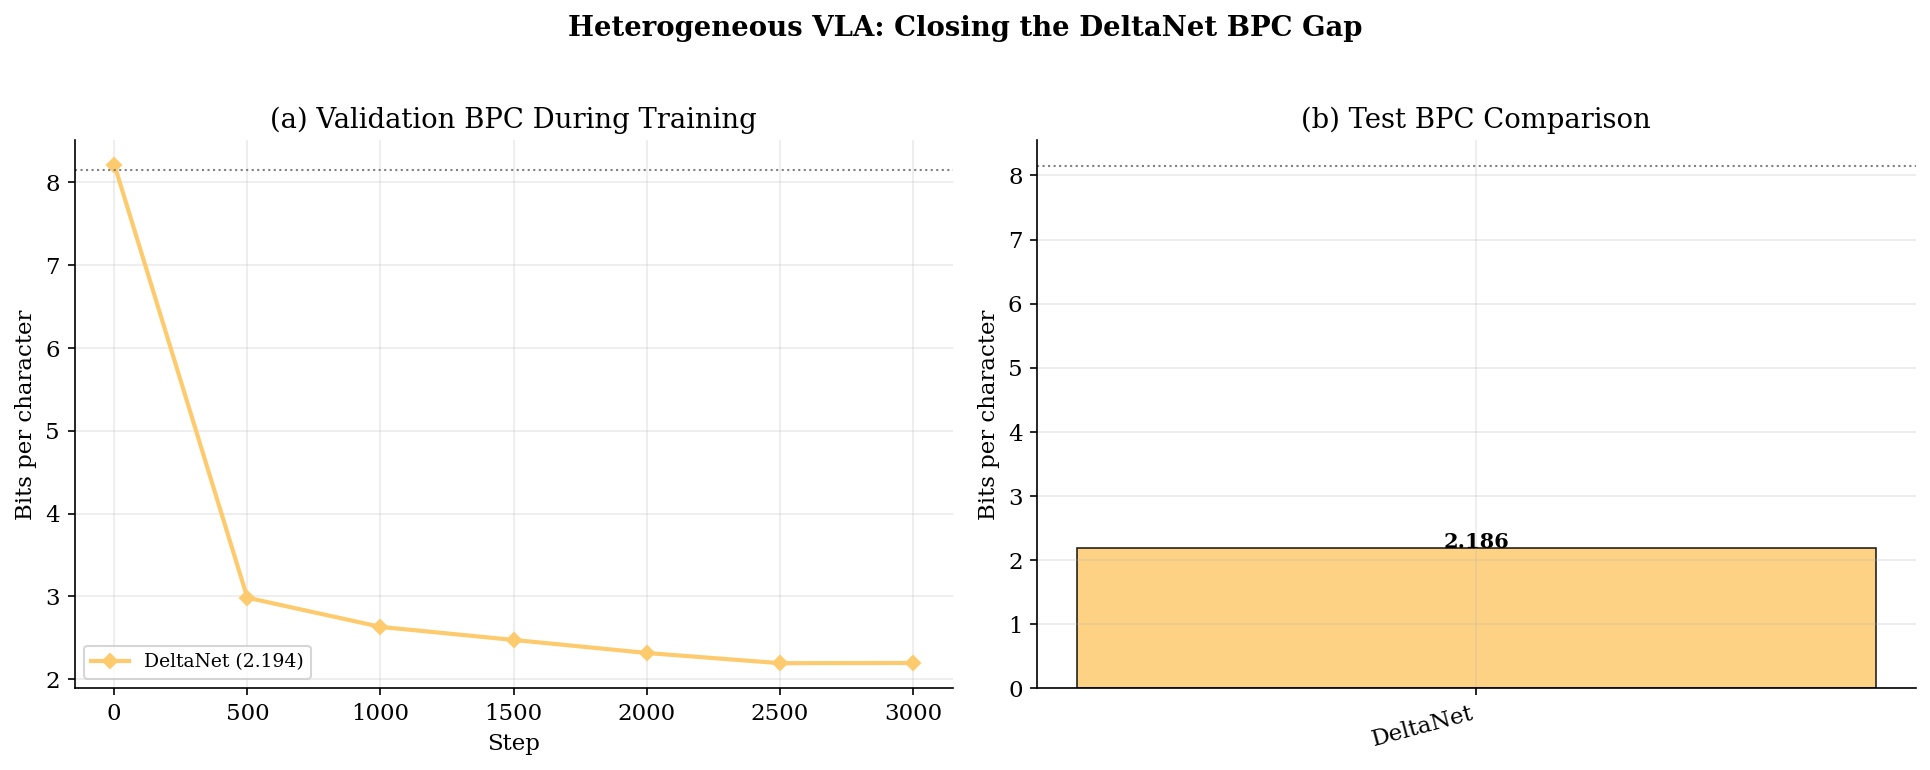

TEST BPC RESULTS:
  DeltaNet            : 2.1858  (+0.0% vs DeltaNet)

All files: /kaggle/working/nb12_hetero
NEXT: if Hetero-VLA-4x closes gap to <5% vs DeltaNet -> update paper


In [6]:
# Test BPC
test_bpcs = {}
for name, model in all_models.items():
    model.eval(); ls=[]
    with torch.no_grad():
        for _ in range(50):
            ix=torch.randint(len(test_data)-SEQ_LEN-1,(BATCH,))
            xt=torch.stack([test_data[i:i+SEQ_LEN] for i in ix]).to(DEVICE)
            yt=torch.stack([test_data[i+1:i+SEQ_LEN+1] for i in ix]).to(DEVICE)
            ls.append(F.cross_entropy(model(xt).view(-1,VOCAB),yt.view(-1)).item())
    test_bpcs[name] = round(float(np.mean(ls))/math.log(2), 4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Training curves
color_map = {
    'Uniform-VLA':   C['vla'],
    'Hetero-VLA-2x': '#74B9FF',
    'Hetero-VLA-4x': C['hetero'],
    'DeltaNet':      C['deltanet'],
}
for name, hist in all_history.items():
    ss  = [h['step']   for h in hist]
    bpc = [h['val_bpc'] for h in hist]
    axes[0].plot(ss, bpc, color=color_map.get(name,'gray'),
                 lw=2, ms=5, marker='D',
                 label=f'{name} ({best_bpcs[name]:.3f})',
                 markevery=max(1,len(ss)//8))

axes[0].axhline(math.log2(VOCAB), color='gray', ls=':', lw=1)
axes[0].set(title='(a) Validation BPC During Training',
            xlabel='Step', ylabel='Bits per character')
axes[0].legend(fontsize=9)

# Panel 2: Test BPC bar
names_sorted = sorted(test_bpcs.keys(), key=lambda n: test_bpcs[n])
bpcs_sorted  = [test_bpcs[n] for n in names_sorted]
bars = axes[1].bar(range(len(names_sorted)), bpcs_sorted,
                    color=[color_map.get(n,'gray') for n in names_sorted],
                    alpha=0.85, edgecolor='black', linewidth=0.8)
for bar, bpc in zip(bars, bpcs_sorted):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.01,
                 f'{bpc:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(range(len(names_sorted)))
axes[1].set_xticklabels([n.replace('-',' ') for n in names_sorted],
                         rotation=15, ha='right')
axes[1].axhline(math.log2(VOCAB), color='gray', ls=':', lw=1)
axes[1].set(title='(b) Test BPC Comparison', ylabel='Bits per character')

plt.suptitle('Heterogeneous VLA: Closing the DeltaNet BPC Gap',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT/'plots'/'paper_figure_nb12.pdf', bbox_inches='tight')
plt.savefig(OUT/'plots'/'paper_figure_nb12.png', dpi=200, bbox_inches='tight')
plt.show()

print('TEST BPC RESULTS:')
for name in sorted(test_bpcs, key=lambda n: test_bpcs[n]):
    bpc = test_bpcs[name]
    dn  = test_bpcs.get('DeltaNet', 999)
    gap = ((bpc - dn)/dn*100) if dn < 999 else 0
    print(f'  {name:20s}: {bpc:.4f}  ({gap:+.1f}% vs DeltaNet)')

# Save
manifest = {
    'val_bpc': best_bpcs, 'test_bpc': test_bpcs,
    'configs': CONFIGS,
    'random_bpc': round(math.log2(VOCAB),4),
}
with open(OUT/'manifest.json','w') as f:
    json.dump(manifest, f, indent=2)
print(f'\nAll files: {OUT}')
print('NEXT: if Hetero-VLA-4x closes gap to <5% vs DeltaNet -> update paper')